# Road2Work Answer Quality Model

Notebook ini sudah dihubungkan dengan file JSON/CSV dari `data_science_resources/`.
Model TensorFlow memprediksi `quality_label` (Weak/Average/Strong) dan `readiness_score` (0–1) agar bisa dihitung Accuracy dan MAE.


In [1]:
from pathlib import Path
import sys, os
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.environ.setdefault('DS_RESOURCES_DIR', str(PROJECT_ROOT / 'data_science_resources'))
print('PROJECT_ROOT:', PROJECT_ROOT)
print('DS_RESOURCES_DIR:', os.environ['DS_RESOURCES_DIR'])


PROJECT_ROOT: d:\Kuliah\Semester 6\Capstone\Capstone Project
DS_RESOURCES_DIR: d:\Kuliah\Semester 6\Capstone\Capstone Project\data_science_resources


In [2]:
from ds_assets import asset_status, get_target_roles, get_role_tree, answer_quality_dataset_path

print('Target roles:', get_target_roles())
print('Dataset path:', answer_quality_dataset_path())
asset_status()


[ds_assets] ✅ Loaded role_tree_dropdown: D:\Kuliah\Semester 6\Capstone\Capstone Project\data_science_resources\role_tree_dropdown.json
Target roles: ['Data Analyst', 'Data Scientist', 'AI Engineer', 'ML Engineer', 'Cloud Engineer', 'DevOps Engineer', 'Cybersecurity Analyst', 'Frontend Developer', 'Backend Developer', 'Full Stack Developer', 'Android Developer', 'iOS Developer', 'Mobile Developer', 'Manual QA Tester', 'QA Automation Engineer', 'Software Tester']
Dataset path: D:\Kuliah\Semester 6\Capstone\Capstone Project\data_science_resources\answer_quality_dataset_synthetic.csv


{'resources_dir': 'D:\\Kuliah\\Semester 6\\Capstone\\Capstone Project\\data_science_resources',
 'auto_reload': True,
 'assets': {'role_tree_dropdown': {'filename': 'role_tree_dropdown.json',
   'path': 'D:\\Kuliah\\Semester 6\\Capstone\\Capstone Project\\data_science_resources\\role_tree_dropdown.json',
   'exists': True,
   'mtime': 1779466448.1769283},
  'role_tree_dropdown_csv': {'filename': 'role_tree_dropdown.csv',
   'path': 'D:\\Kuliah\\Semester 6\\Capstone\\Capstone Project\\data_science_resources\\role_tree_dropdown.csv',
   'exists': True,
   'mtime': 1779466448.1662078},
  'role_skill_matrix': {'filename': 'role_skill_matrix.json',
   'path': 'D:\\Kuliah\\Semester 6\\Capstone\\Capstone Project\\data_science_resources\\role_skill_matrix.json',
   'exists': True,
   'mtime': 1779466448.1526556},
  'role_skill_matrix_csv': {'filename': 'role_skill_matrix.csv',
   'path': 'D:\\Kuliah\\Semester 6\\Capstone\\Capstone Project\\data_science_resources\\role_skill_matrix.csv',
   'ex

In [3]:
import pandas as pd
dataset_path = answer_quality_dataset_path()
df = pd.read_csv(dataset_path)
print(df.shape)
df.head()


(1002, 26)


,sample_id,domain,role_family,target_role,competency,question,answer,role_relevance,star_structure,evidence_specificity,...,clarification_type,final_score_0_100,final_score_0_1,quality_label,has_tool,has_metric,has_impact,has_action,has_context,answer_length_words
0,AQD-27DE8C,Information & Technology,Data & AI,Data Analyst,Career Motivation & Fit,"Halo, selamat datang di sesi wawancara. Bisa c...","Ehm... saya... ya, saya sebenarnya... ehh, sek...",25,20.0,25,...,context,22.75,0.2275,Weak,0,0,0,0,0,101
1,AQD-FBD3C1,Information & Technology,Data & AI,Data Analyst,Career Motivation & Fit,"Halo, selamat datang di sesi wawancara. Bisa c...","Eeeh, halo, Pak/Bu. Selamat siang. Jadi, kalau...",65,45.0,50,...,metric,59.05,0.5905,Average,1,0,1,1,1,217
2,AQD-6FCBC8,Information & Technology,Data & AI,Data Analyst,Career Motivation & Fit,"Halo, selamat datang di sesi wawancara. Bisa c...","Halo, terima kasih atas kesempatannya. Nama sa...",95,95.0,95,...,none,93.75,0.9375,Strong,1,1,1,1,1,310
3,AQD-6A3167,Information & Technology,Data & AI,Data Analyst,Career Motivation & Fit,Dari semua project atau materi yang pernah kam...,"Emm... ya, kalo soal yang bikin 'klik' ya... k...",25,0.0,15,...,context,16.25,0.1625,Weak,1,0,0,1,0,49
4,AQD-46DE80,Information & Technology,Data & AI,Data Analyst,Career Motivation & Fit,Dari semua project atau materi yang pernah kam...,"Ehm, kalau yang bikin saya merasa paling 'klik...",80,55.0,50,...,contribution,64.00,0.6400,Average,0,0,1,1,1,147


In [4]:
df['quality_label'].value_counts(), df[['final_score_0_1','quality_label']].describe()


(quality_label
 Weak       334
 Average    334
 Strong     334
 Name: count, dtype: int64,
        final_score_0_1
 count      1002.000000
 mean          0.593579
 std           0.280847
 min           0.105000
 25%           0.267500
 50%           0.600000
 75%           0.927500
 max           0.975000)

## Train Model
Jalankan cell ini saat TensorFlow sudah terinstall. Untuk demo cepat, kurangi `epochs`.


In [5]:
from model_builder import train_answer_quality_model, ANSWER_QUALITY_MODEL_PATH

model = train_answer_quality_model(
    csv_path=str(dataset_path),
    epochs=25,
    min_accuracy=0.85,
    max_mae=0.02,
)
print('Saved model:', ANSWER_QUALITY_MODEL_PATH)


d:\Virtual Environment\machine_learning\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


[ds_assets] ✅ Loaded role_skill_matrix: D:\Kuliah\Semester 6\Capstone\Capstone Project\data_science_resources\role_skill_matrix.json
[model_builder] ✅ Role matrix DS aktif (16 role).
Epoch 1/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - answer_quality_accuracy: 0.5564 - answer_quality_loss: 1.0003 - loss: 1.1138 - readiness_score_loss: 0.2266 - readiness_score_mae: 0.2266[callback] epoch=1 accuracy=0.9701 mae=0.1532
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 197ms/step - answer_quality_accuracy: 0.7054 - answer_quality_loss: 0.8804 - loss: 0.9937 - readiness_score_loss: 0.2131 - readiness_score_mae: 0.2115 - val_answer_quality_accuracy: 0.9701 - val_answer_quality_loss: 0.5226 - val_loss: 0.6024 - val_readiness_score_loss: 0.1547 - val_readiness_score_mae: 0.1532
Epoch 2/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - answer_quality_accuracy: 0.8766 - answer_quality_loss: 0.4373 - loss: 0.5063 - readiness_score_loss: 0.1378 - readiness_score_mae: 0.1377[callback] epoch=2 accuracy=0.9900 mae=0.0840
2

Available history keys:
- answer_quality_accuracy
- answer_quality_loss
- loss
- readiness_score_loss
- readiness_score_mae
- val_answer_quality_accuracy
- val_answer_quality_loss
- val_loss
- val_readiness_score_loss
- val_readiness_score_mae


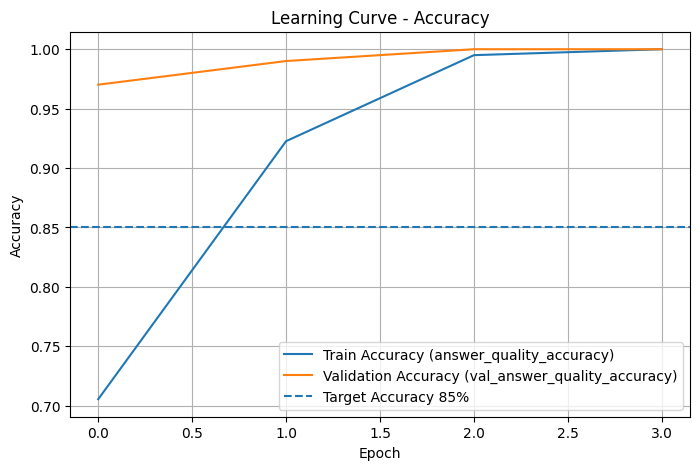

Final Train Accuracy     : 1.0000
Final Validation Accuracy: 1.0000


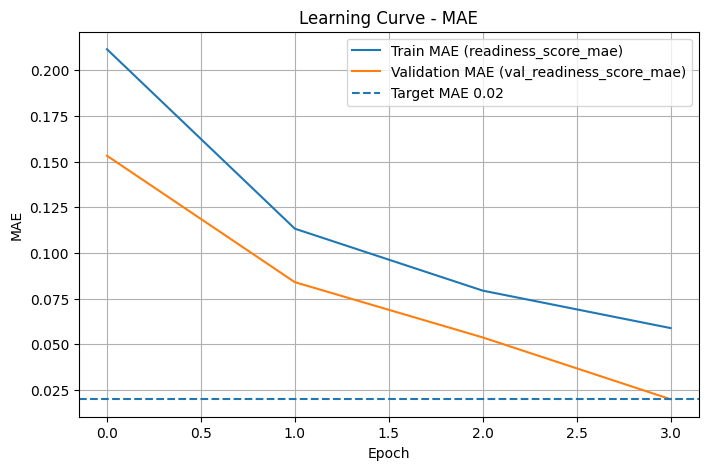

Final Train MAE     : 0.0589
Final Validation MAE: 0.0199


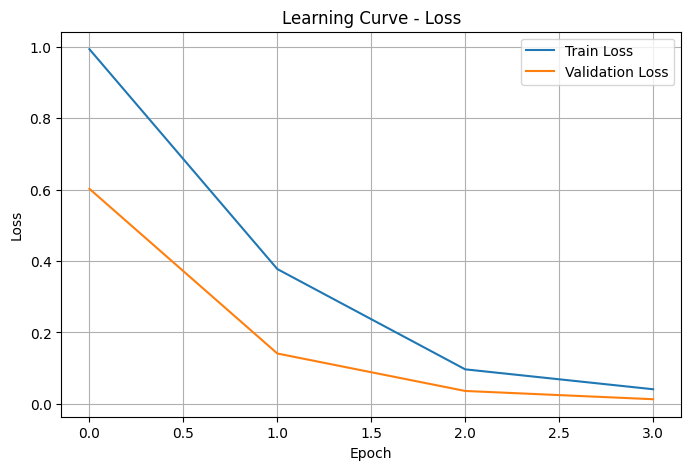

Final Train Loss     : 0.0408
Final Validation Loss: 0.0128

=== Final Performance Check ===
Validation Accuracy: 1.0000 | Target >= 0.85 | PASS
Validation MAE     : 0.0199 | Target <= 0.02 | PASS

Model memenuhi target performa.


In [6]:
# ============================================================
# Learning Curve — Accuracy & MAE
# Road2Work Answer Quality Model
# ============================================================

import matplotlib.pyplot as plt

# Ambil history dari hasil training
# Pastikan sebelumnya kamu training seperti:
# history = model.fit(...)

hist = model.history.history

print("Available history keys:")
for key in hist.keys():
    print("-", key)


def find_metric_key(history_dict, keyword, prefer_contains=None, val=False):
    """
    Cari nama metric secara otomatis dari history Keras.
    Cocok untuk model single-output maupun multi-output.
    """
    keys = list(history_dict.keys())

    if val:
        keys = [k for k in keys if k.startswith("val_")]
    else:
        keys = [k for k in keys if not k.startswith("val_")]

    keys = [k for k in keys if keyword.lower() in k.lower()]

    if prefer_contains:
        preferred = [
            k for k in keys 
            if prefer_contains.lower() in k.lower()
        ]
        if preferred:
            return preferred[0]

    return keys[0] if keys else None


# =========================
# 1. Accuracy Learning Curve
# =========================

train_acc_key = (
    find_metric_key(hist, "accuracy", prefer_contains="quality", val=False)
    or find_metric_key(hist, "accuracy", prefer_contains="label", val=False)
    or find_metric_key(hist, "accuracy", val=False)
)

val_acc_key = (
    find_metric_key(hist, "accuracy", prefer_contains="quality", val=True)
    or find_metric_key(hist, "accuracy", prefer_contains="label", val=True)
    or find_metric_key(hist, "accuracy", val=True)
)

if train_acc_key and val_acc_key:
    plt.figure(figsize=(8, 5))
    plt.plot(hist[train_acc_key], label=f"Train Accuracy ({train_acc_key})")
    plt.plot(hist[val_acc_key], label=f"Validation Accuracy ({val_acc_key})")
    plt.axhline(y=0.85, linestyle="--", label="Target Accuracy 85%")

    plt.title("Learning Curve - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Final Train Accuracy     : {hist[train_acc_key][-1]:.4f}")
    print(f"Final Validation Accuracy: {hist[val_acc_key][-1]:.4f}")

else:
    print("Metric accuracy tidak ditemukan di history.")


# ===================
# 2. MAE Learning Curve
# ===================

train_mae_key = (
    find_metric_key(hist, "mae", prefer_contains="score", val=False)
    or find_metric_key(hist, "mae", prefer_contains="readiness", val=False)
    or find_metric_key(hist, "mae", val=False)
)

val_mae_key = (
    find_metric_key(hist, "mae", prefer_contains="score", val=True)
    or find_metric_key(hist, "mae", prefer_contains="readiness", val=True)
    or find_metric_key(hist, "mae", val=True)
)

if train_mae_key and val_mae_key:
    plt.figure(figsize=(8, 5))
    plt.plot(hist[train_mae_key], label=f"Train MAE ({train_mae_key})")
    plt.plot(hist[val_mae_key], label=f"Validation MAE ({val_mae_key})")
    plt.axhline(y=0.02, linestyle="--", label="Target MAE 0.02")

    plt.title("Learning Curve - MAE")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Final Train MAE     : {hist[train_mae_key][-1]:.4f}")
    print(f"Final Validation MAE: {hist[val_mae_key][-1]:.4f}")

else:
    print("Metric MAE tidak ditemukan di history.")


# ===================
# 3. Loss Learning Curve
# ===================

if "loss" in hist and "val_loss" in hist:
    plt.figure(figsize=(8, 5))
    plt.plot(hist["loss"], label="Train Loss")
    plt.plot(hist["val_loss"], label="Validation Loss")

    plt.title("Learning Curve - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Final Train Loss     : {hist['loss'][-1]:.4f}")
    print(f"Final Validation Loss: {hist['val_loss'][-1]:.4f}")

else:
    print("Metric loss / val_loss tidak ditemukan di history.")


# ===================
# 4. Final Status Check
# ===================

print("\n=== Final Performance Check ===")

if val_acc_key and val_mae_key:
    final_val_acc = hist[val_acc_key][-1]
    final_val_mae = hist[val_mae_key][-1]

    acc_pass = final_val_acc >= 0.85
    mae_pass = final_val_mae <= 0.02

    print(f"Validation Accuracy: {final_val_acc:.4f} | Target >= 0.85 | {'PASS' if acc_pass else 'NOT PASS'}")
    print(f"Validation MAE     : {final_val_mae:.4f} | Target <= 0.02 | {'PASS' if mae_pass else 'NOT PASS'}")

    if acc_pass and mae_pass:
        print("\nModel memenuhi target performa.")
    else:
        print("\nModel belum memenuhi target performa. Perlu tuning model, dataset, atau preprocessing.")
else:
    print("Tidak bisa cek final performance karena metric accuracy atau MAE tidak lengkap.")

## Evaluate Saved Model — Synthetic + Realistic Manual Test

Cell ini mengecek performa model di dataset synthetic DS dan external manual test yang lebih realistis.

In [7]:
from model_builder import evaluate_saved_model, evaluate_saved_model_detailed, manual_test_dataset_path

# 1) Evaluasi di dataset synthetic utama
synthetic_result = evaluate_saved_model(csv_path=str(dataset_path))
print("=== Synthetic Dataset Evaluation ===")
for key, value in synthetic_result.items():
    print(f"{key}: {value:.4f}")

# 2) Evaluasi external di dataset manual/realistic
manual_path = manual_test_dataset_path()
print("\nManual test path:", manual_path)
manual_result = evaluate_saved_model_detailed(csv_path=manual_path, include_predictions=True)
print("\n=== Realistic Manual Test Evaluation ===")
print(f"Samples : {manual_result['n_samples']}")
print(f"Accuracy: {manual_result['answer_quality_accuracy']:.4f} | Target >= 0.85 | {'PASS' if manual_result['target_accuracy_pass'] else 'NOT PASS'}")
print(f"MAE     : {manual_result['readiness_score_mae']:.4f} | Target <= 0.02 | {'PASS' if manual_result['target_mae_pass'] else 'NOT PASS'}")
print("Per-class accuracy:", manual_result['per_class_accuracy'])
manual_result['confusion_matrix_readable']


=== Synthetic Dataset Evaluation ===
answer_quality_accuracy: 1.0000
answer_quality_loss: 0.0028
loss: 0.0140
readiness_score_loss: 0.0221
readiness_score_mae: 0.0223

Manual test path: D:\Kuliah\Semester 6\Capstone\Capstone Project\data_science_resources\answer_quality_manual_test.csv

=== Realistic Manual Test Evaluation ===
Samples : 54
Accuracy: 0.3333 | Target >= 0.85 | NOT PASS
MAE     : 0.2251 | Target <= 0.02 | NOT PASS
Per-class accuracy: {'Weak': 0.0, 'Average': 0.0, 'Strong': 1.0}


{'Weak': {'Weak': 0, 'Average': 2, 'Strong': 16},
 'Average': {'Weak': 0, 'Average': 0, 'Strong': 18},
 'Strong': {'Weak': 0, 'Average': 0, 'Strong': 18}}

## Confusion Matrix — Realistic Manual Test

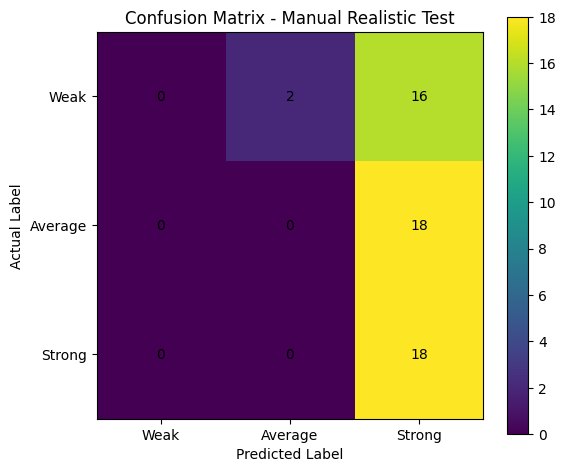

In [8]:
import matplotlib.pyplot as plt
import numpy as np

labels = manual_result["labels"]
cm = np.array(manual_result["confusion_matrix"])

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - Manual Realistic Test")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()


## Inspect Wrong Predictions

In [9]:
import pandas as pd

pred_df = pd.DataFrame(manual_result.get("predictions", []))
wrong_df = pred_df[pred_df["correct"] == False]
print("Wrong predictions:", wrong_df.shape[0])
wrong_df.head(20)


Wrong predictions: 36


,sample_id,target_role,actual_label,predicted_label,actual_score,predicted_score,correct
0,MAN-01-WEA,Data Analyst,Weak,Average,0.373,0.7668,False
1,MAN-01-AVE,Data Analyst,Average,Strong,0.643,0.8190,False
3,MAN-02-WEA,Data Scientist,Weak,Strong,0.373,0.7911,False
4,MAN-02-AVE,Data Scientist,Average,Strong,0.643,0.8407,False
6,MAN-03-WEA,AI Engineer,Weak,Strong,0.373,0.7942,False
7,MAN-03-AVE,AI Engineer,Average,Strong,0.643,0.8398,False
9,MAN-04-WEA,ML Engineer,Weak,Strong,0.373,0.8130,False
10,MAN-04-AVE,ML Engineer,Average,Strong,0.643,0.8497,False
12,MAN-05-WEA,Cloud Engineer,Weak,Strong,0.373,0.8826,False
13,MAN-05-AVE,Cloud Engineer,Average,Strong,0.643,0.9053,False


## Inference Test


In [10]:
from model_builder import predict_answer_quality

result = predict_answer_quality(
    question='Ceritakan project AI yang pernah kamu buat.',
    answer='Saya membuat model klasifikasi teks menggunakan Python dan TensorFlow. Saya bertanggung jawab membersihkan data, melatih model, dan mengevaluasi akurasi sampai 88%.',
    role='AI Engineer',
)
result


{'label': 'Strong',
 'confidence': 0.994,
 'supporting_readiness_score': 92,
 'supporting_score_0_1': 0.9187,
 'probabilities': {'Weak': 0.0, 'Average': 0.0058, 'Strong': 0.9941},
 'features': {'has_tool': 1,
  'has_metric': 1,
  'has_impact': 1,
  'has_action': 1,
  'has_context': 1,
  'evidence_level': 5,
  'evidence_level_norm': 1.0,
  'answer_length_words_norm': 0.084,
  'answer_length_words_estimate': 21},
 'source': 'tensorflow_model'}